In [67]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

pd.set_option("display.max_column",None)

In [68]:
df = pd.read_csv("../data/cleaned/superstore_cleaned.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [70]:
total_sales = df["Sales"].sum()

print(f"Total Revenue: ${total_sales:,.2f}")

Total Revenue: $2,297,200.86


In [71]:
total_profit = df["Profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [72]:
total_orders = df["Order ID"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 5009


In [73]:
total_customers = df["Customer ID"].nunique()

print(f"Total Customers: {total_customers}")

Total Customers: 793


In [74]:
total_products = df["Product ID"].nunique()

print(f"Total Products: {total_products}")

Total Products: 1862


In [75]:
average_order_value = total_sales / total_orders

print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $458.61


In [76]:
total_products = df["Product ID"].nunique()

print(f"Total Products: {total_products}")

Total Products: 1862


In [77]:
average_order_value = total_sales / total_orders

print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $458.61


In [78]:
kpi = pd.DataFrame({
    "Metric": [
        "Revenue",
        "Profit",
        "Orders",
        "Customers",
        "Products",
        "Average Order Value"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        total_products,
        average_order_value
    ]
})

kpi

,Metric,Value
0,Revenue,2.297201e+06
1,Profit,2.863970e+05
2,Orders,5.009000e+03
3,Customers,7.930000e+02
4,Products,1.862000e+03
5,Average Order Value,4.586147e+02


In [79]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

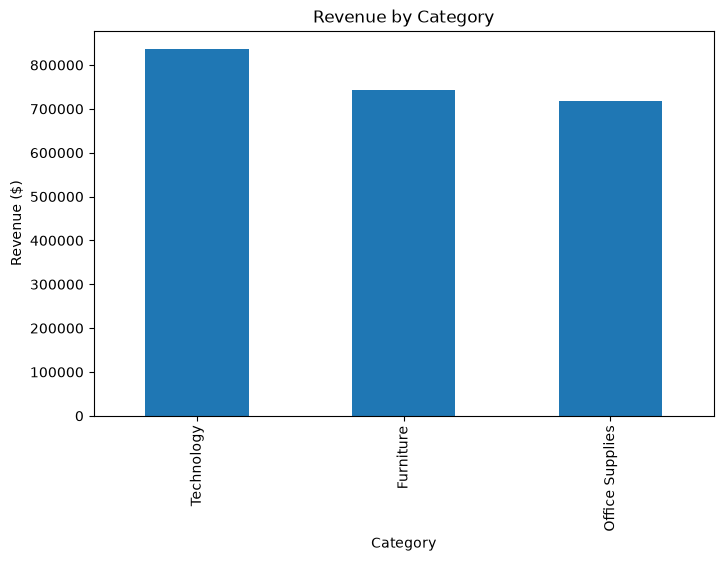

In [80]:
category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")

plt.show()

In [81]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [82]:
subcategory_sales.head(10)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

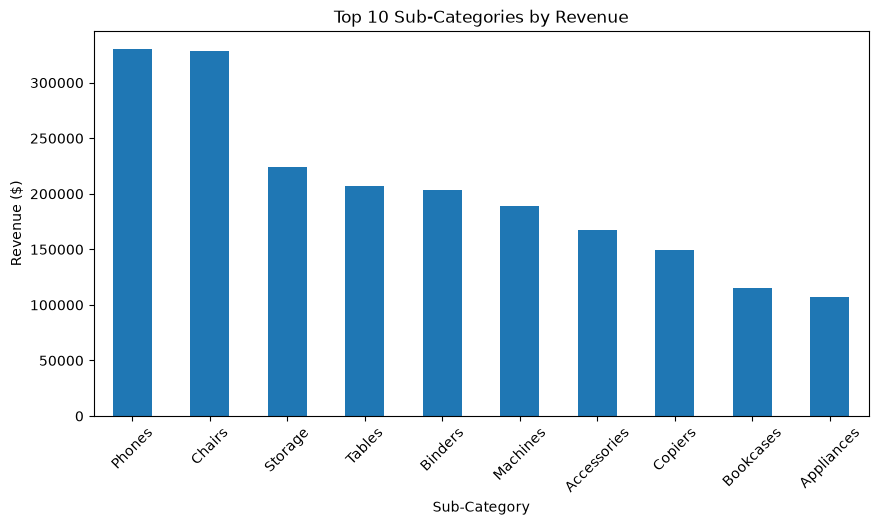

In [83]:
subcategory_sales.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Sub-Categories by Revenue")
plt.xlabel("Sub-Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.show()

In [84]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

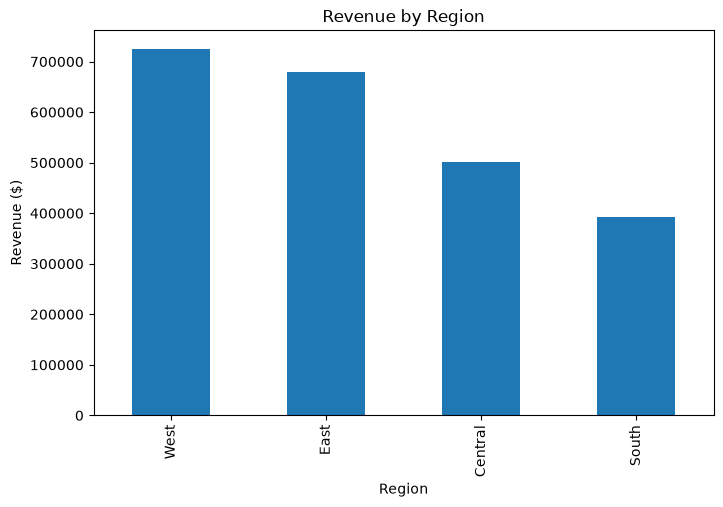

In [85]:
region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue ($)")

plt.show()

In [86]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

region_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

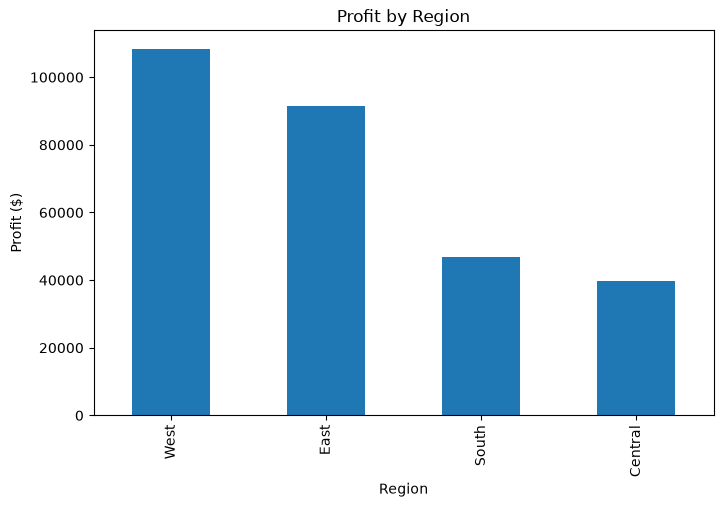

In [87]:
region_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")

plt.show()

In [88]:
region_summary = (
    df.groupby("Region")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values(by="Revenue", ascending=False)
)

region_summary

,Revenue,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [89]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

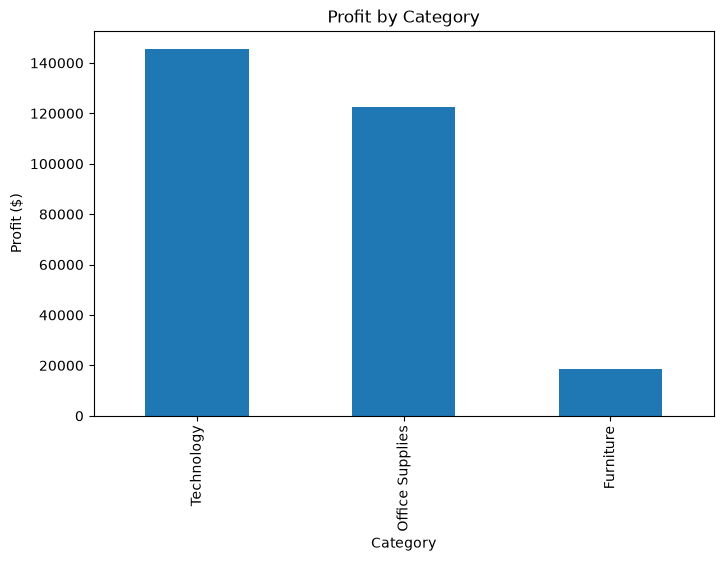

In [90]:
category_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")

plt.show()

In [91]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_profit

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [92]:
subcategory_profit.head(10)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Name: Profit, dtype: float64

In [93]:
subcategory_profit.tail(10)

Sub-Category
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

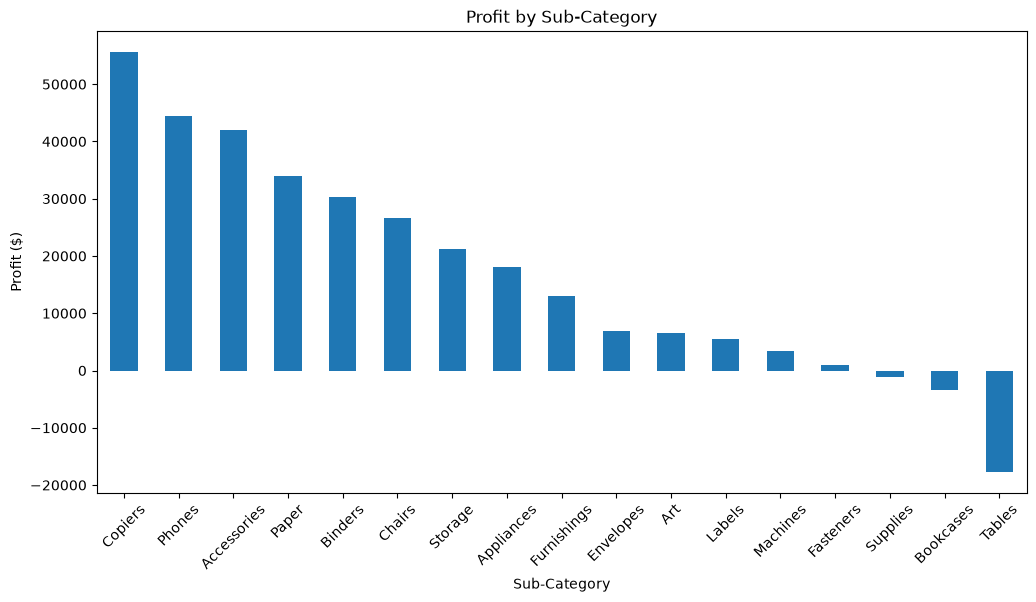

In [94]:
subcategory_profit.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)

plt.show()

In [95]:
loss_products = subcategory_profit[subcategory_profit < 0]

loss_products

Sub-Category
Supplies     -1189.0995
Bookcases    -3472.5560
Tables      -17725.4811
Name: Profit, dtype: float64

In [96]:
customer_sales = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

customer_sales.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

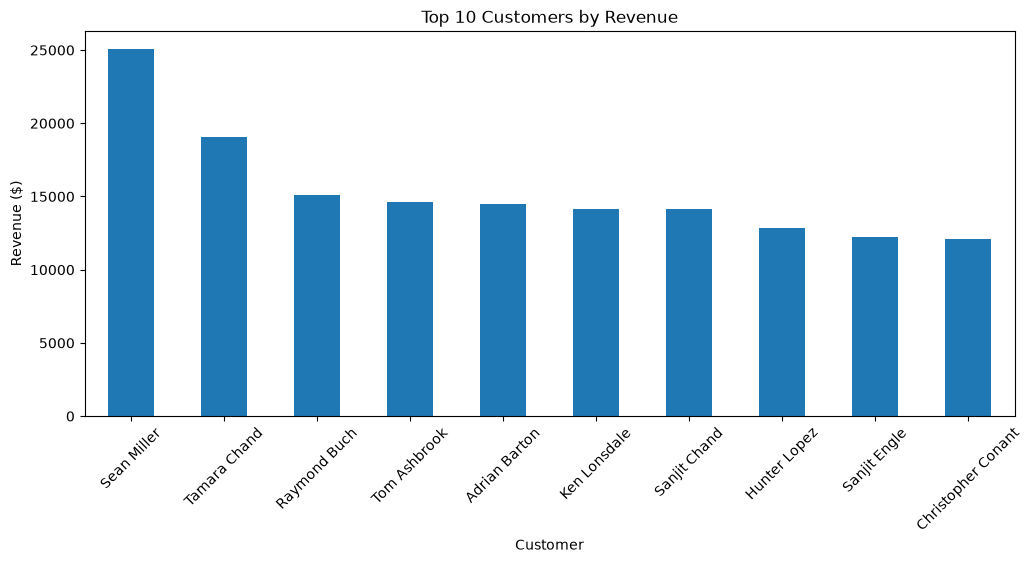

In [97]:
customer_sales.head(10).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.show()

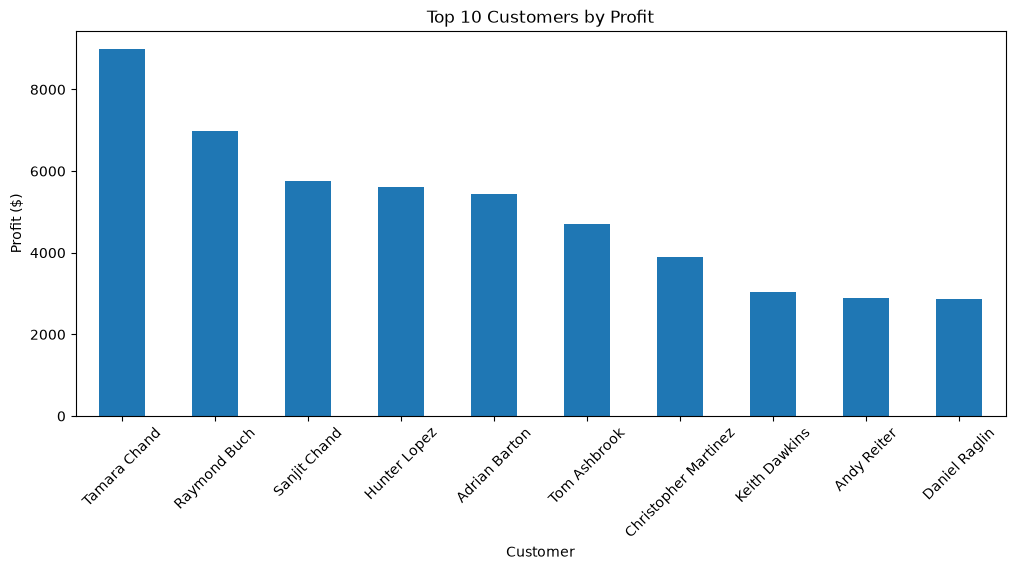

In [98]:
customer_profit = (
    df.groupby("Customer Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

customer_profit.head(10)

customer_profit.head(10).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Customer")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)

plt.show()

In [99]:
customer_summary = (
    df.groupby("Customer Name")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .sort_values(by="Revenue", ascending=False)
)

customer_summary.head(10)

,Revenue,Profit,Orders
Customer Name,,,
Sean Miller,25043.050,-1980.7393,5
Tamara Chand,19052.218,8981.3239,5
Raymond Buch,15117.339,6976.0959,6
Tom Ashbrook,14595.620,4703.7883,4
Adrian Barton,14473.571,5444.8055,10
Ken Lonsdale,14175.229,806.8550,12
Sanjit Chand,14142.334,5757.4119,9
Hunter Lopez,12873.298,5622.4292,6
Sanjit Engle,12209.438,2650.6769,11


In [100]:
sales_year = (
    df.groupby("Order Year")["Sales"]
      .sum()
      .sort_values()
)

sales_year

sales_year.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Revenue ($)")

plt.grid(True)

plt.show()

KeyError: 'Order Year'

In [ ]:
profit_year = (
    df.groupby("Order Year")["Profit"]
      .sum()
      .sort_index()
)

profit_year

profit_year.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Yearly Profit Trend")
plt.xlabel("Year")
plt.ylabel("Profit ($)")
plt.grid(True)

plt.show()

In [ ]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

sales_month = (
    df.groupby("Order Month")["Sales"]
      .sum()
      .reindex(month_order)
)

sales_month


sales_month.plot(
    kind="line",
    marker="o",
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
profit_month = (
    df.groupby("Order Month")["Profit"]
      .sum()
      .reindex(month_order)
)

profit_month


profit_month.plot(
    kind="line",
    marker="o",
    figsize=(12,5)
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
quarter_sales = (
    df.groupby("Order Quarter")["Sales"]
      .sum()
      .sort_index()
)

quarter_sales

quarter_sales.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Quarterly Sales")
plt.xlabel("Quarter")
plt.ylabel("Revenue ($)")

plt.show()

In [ ]:
ship_sales = (
    df.groupby("Ship Mode")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

ship_sales

ship_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Revenue ($)")

plt.show()

In [ ]:
shipping_days = (
    df.groupby("Ship Mode")["Shipping Days"]
      .mean()
      .sort_values()
)

shipping_days

In [ ]:
discount_summary = (
    df.groupby("Discount")[["Sales","Profit"]]
      .mean()
)

discount_summary

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [ ]:
numeric = df[
    [
        "Sales",
        "Profit",
        "Quantity",
        "Discount",
        "Shipping Days"
    ]
]

correlation = numeric.corr()

correlation


In [ ]:
plt.figure(figsize=(6,5))

plt.imshow(
    correlation,
    cmap="coolwarm"
)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.show()